# Modelo de Clasificación mediante K-Nearest Neighbors (KNN) para la predicción de niveles de TCH y Sacarosa

Este cuaderno tiene como objetivo desarrollar un modelo de clasificación basado en el algoritmo de K-Nearest Neighbors (KNN) para predecir los niveles de productividad de la caña de azúcar, específicamente el TCH (Toneladas de Caña por Hectárea) y el contenido de sacarosa.

Para ello, se utilizan datos históricos suministrados por el Ingenio Providencia, los cuales contienen información agronómica, climática y de manejo del cultivo. Las variables continuas de interés son transformadas en categorías (Bajo, Medio y Alto), permitiendo abordar el problema como una tarea de clasificación multiclase.

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score
)

import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.evaluation import evaluar_modelo

## 2. Carga de datos

El dataset `BD_IPSA_1940.xlsx` contiene información histórica sobre variables agronómicas, ambientales y de manejo del cultivo de caña de azúcar. Este conjunto de datos será utilizado para entrenar y evaluar los modelos de clasificación orientados a predecir los niveles de TCH y sacarosa.

In [2]:
RAW_DATA_PATH_1 = '../data/processed/datos_limpios_clasificacion_tch.csv'
RAW_DATA_PATH_2 = '../data/processed/datos_limpios_clasificacion_sacarosa.csv'

data_tch = pd.read_csv(RAW_DATA_PATH_1)
data_sac = pd.read_csv(RAW_DATA_PATH_2)

## 3. Creación de clases para las variables objetivo

Con el fin de abordar el problema como una tarea de clasificación multiclase, las variables continuas `TCH` y `sacarosa` se discretizan en tres categorías: Bajo, Medio y Alto.

In [3]:
map_clases = {
    0: "Bajo",
    1: "Medio",
    2: "Alto"
}

data_tch["TCH_clase"] = data_tch["Clase_TCH"].map(map_clases)
data_sac["sacarosa_clase"] = data_sac["Clase_Sacarosa"].map(map_clases)

## 4. Definición de variables predictoras

Se seleccionan variables relevantes desde el punto de vista agronómico, relacionadas con el desarrollo del cultivo, las condiciones climáticas, el manejo agrícola y las características del lote.

Estas variables se consideran potencialmente influyentes en el rendimiento y la calidad de la caña, por lo que pueden aportar información valiosa para la clasificación de los niveles de TCH y sacarosa.

In [4]:
features = [
    "dosismad",
    "semsmad",
    "edad",
    "cortes",
    "me",
    "vejez",
    "lluvias",
    "pct_diatrea"
]

## 5. Modelo KNN para TCH

### 5.1 Definición de variables y partición de datos

En esta etapa, se define `TCH_clase` como variable objetivo y se seleccionan las variables predictoras previamente establecidas. Posteriormente, el conjunto de datos se divide en entrenamiento (80%) y prueba (20%).

Se utiliza estratificación mediante `stratify=y` con el fin de conservar la proporción de clases en ambos subconjuntos, lo que permite obtener una evaluación más representativa del desempeño del modelo.

In [5]:
X = data_tch[features]
y = data_tch["TCH_clase"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 5.2 Preprocesamiento de datos

Las variables numéricas se imputan con la mediana y posteriormente se escalan mediante `StandardScaler`. Las variables categóricas se imputan con la moda y se codifican a través de `OneHotEncoder`.

Este paso es fundamental en KNN, ya que el modelo se basa en distancias y es altamente sensible a la escala de los datos. Sin una estandarización adecuada, las variables con mayor magnitud podrían dominar el cálculo de distancias y afectar negativamente el desempeño del modelo.

In [6]:
numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categoricas = X.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numericas),
    ("cat", categorical_transformer, categoricas)
])

### 5.3 Construcción del pipeline

Se construye un pipeline que integra el preprocesamiento de los datos con el modelo KNN en un único flujo de trabajo. Esto garantiza que todas las transformaciones (imputación, escalado y codificación) se apliquen de manera consistente tanto en el entrenamiento como en la evaluación del modelo, evitando fugas de información (data leakage).

In [7]:
pipe_knn = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

### 5.4 Búsqueda de hiperparámetros

Se optimizan los principales hiperparámetros del modelo KNN mediante validación cruzada estratificada. En particular, se evalúa el número de vecinos (`k`) y el tipo de ponderación (`weights`).

El número de vecinos controla el nivel de generalización del modelo: valores pequeños pueden generar sobreajuste, mientras que valores grandes pueden suavizar en exceso la frontera de decisión. Por su parte, el parámetro `weights` permite asignar mayor importancia a los vecinos más cercanos, lo cual puede mejorar el desempeño en conjuntos de datos con solapamiento entre clases.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "model__n_neighbors": list(range(3, 16, 2)),
    "model__weights": ["uniform", "distance"]
}

grid_knn = GridSearchCV(
    pipe_knn,
    param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

### 5.5 Entrenamiento del modelo

Se entrena el modelo utilizando `GridSearchCV` sobre el conjunto de entrenamiento (`X_train`, `y_train`). Después del entrenamiento, se muestran los mejores hiperparámetros encontrados y el mejor puntaje de F1 macro obtenido durante la validación cruzada.

In [9]:
grid_knn.fit(X_train, y_train)

best_model_knn = grid_knn.best_estimator_

print("Mejores hiperparámetros:", grid_knn.best_params_)
print("Mejor F1 CV:", grid_knn.best_score_)

Mejores hiperparámetros: {'model__n_neighbors': 3, 'model__weights': 'distance'}
Mejor F1 CV: 0.45103785393656104


El mejor modelo encontrado utiliza `k = 3` vecinos con ponderación por distancia (`weights = distance`). Este resultado sugiere que dar mayor importancia a los vecinos más cercanos mejora la capacidad del modelo para capturar patrones locales en los datos.

El F1 macro obtenido en validación cruzada fue de aproximadamente **0.4510**, lo cual indica un desempeño moderado. Aunque este valor es ligeramente inferior al obtenido por la regresión logística en validación cruzada para TCH, el modelo KNN sigue siendo relevante porque permite evaluar un enfoque no lineal basado en similitud entre observaciones.

### 6.6 Evaluación del modelo

El modelo KNN presenta un F1 macro de aproximadamente 0.49, lo cual representa una mejora frente al modelo de regresión logística. Esto indica que el enfoque basado en vecinos permite capturar mejor la estructura de los datos.

Se observa que las clases "Alto" y "Bajo" presentan un desempeño más equilibrado, mientras que la clase "Medio" sigue siendo la más difícil de clasificar. Este comportamiento es consistente con la presencia de solapamiento entre clases en el espacio de características.

El valor del índice de Cohen’s Kappa (≈ 0.24) indica un acuerdo moderado entre las predicciones del modelo y los valores reales, lo que sugiere que, aunque el modelo mejora respecto a la regresión logística, aún existen limitaciones en la separabilidad de las clases.

Accuracy: 0.4132420091324201
F1 Macro: 0.4143531808858809
              precision    recall  f1-score   support

        Alto       0.37      0.40      0.39       148
        Bajo       0.48      0.42      0.45       146
       Medio       0.40      0.42      0.41       144

    accuracy                           0.41       438
   macro avg       0.42      0.41      0.41       438
weighted avg       0.42      0.41      0.41       438

--- REPORTE DE RESULTADOS ---
F1-Score (Macro) : 0.4144
Cohen's Kappa    : 0.1198


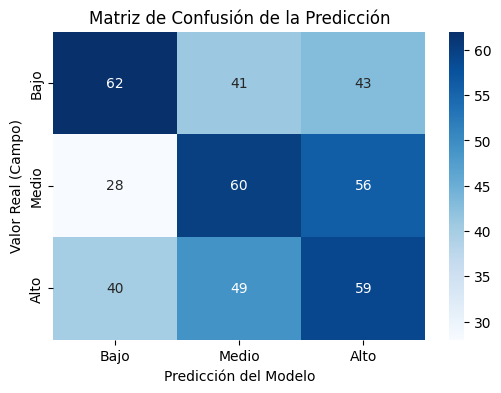

(0.4143531808858809,
 0.11975289333750394,
 array([[62, 41, 43],
        [28, 60, 56],
        [40, 49, 59]]))

In [11]:

y_pred_knn = best_model_knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("F1 Macro:", f1_score(y_test, y_pred_knn, average="macro"))
print(classification_report(y_test, y_pred_knn))
evaluar_modelo(y_test, y_pred_knn)

El modelo KNN obtuvo un desempeño moderado-bajo en la clasificación de TCH, con un F1 macro de aproximadamente 0.4144 y un Accuracy de 0.4132. Estos resultados indican que el modelo tiene dificultades para separar adecuadamente las tres clases.

A diferencia de lo esperado, KNN no superó el desempeño de la regresión logística para esta variable objetivo. Esto sugiere que, aunque KNN puede capturar patrones locales, la estructura de los datos no presenta vecindarios suficientemente claros para mejorar la clasificación.

La matriz de confusión muestra errores distribuidos entre las tres clases, lo cual evidencia un alto solapamiento en el espacio de características. Además, el valor de Cohen’s Kappa de 0.1198 indica un bajo nivel de acuerdo entre las predicciones y los valores reales.

## 6. Modelo KNN para la predicción de sacarosa

El modelo KNN permite capturar patrones locales en los datos, lo cual puede mejorar la clasificación frente a modelos lineales. Si el desempeño es superior al de la regresión logística, esto indicaría que las relaciones entre variables son de tipo no lineal.

### 6.1 Definición de variables y partición de datos

En esta sección, se define `sacarosa_clase` como variable objetivo, manteniendo el mismo conjunto de variables predictoras utilizado previamente. Esto permite comparar de manera consistente el desempeño del modelo entre TCH y sacarosa.

Posteriormente, el conjunto de datos se divide en entrenamiento (80%) y prueba (20%), utilizando estratificación para preservar la proporción de clases.

In [12]:
X_sac = data_sac[features]
y_sac = data_sac["sacarosa_clase"]

X_train_sac, X_test_sac, y_train_sac, y_test_sac = train_test_split(
    X_sac, y_sac,
    test_size=0.2,
    random_state=42,
    stratify=y_sac
)

### 6.2 Entrenamiento del modelo para la clasificación de sacarosa

Se entrena el modelo KNN utilizando validación cruzada (`GridSearchCV`) sobre el conjunto de entrenamiento, con el objetivo de identificar la mejor combinación de hiperparámetros para la predicción de `sacarosa_clase`.

Se utiliza la misma configuración empleada en el modelo de TCH, lo que permite mantener consistencia metodológica y facilitar la comparación entre ambos resultados.

In [13]:
grid_knn_sac = GridSearchCV(pipe_knn, param_grid, cv=cv, scoring="f1_macro")

grid_knn_sac.fit(X_train_sac, y_train_sac)

best_knn_sac = grid_knn_sac.best_estimator_

### 6.3 Evaluación del modelo

El modelo entrenado se evalúa sobre el conjunto de prueba utilizando el F1 macro como métrica principal, ya que permite medir el desempeño del modelo considerando todas las clases de forma equilibrada.

Este análisis permite determinar si el modelo KNN logra capturar de manera efectiva los patrones asociados a la variable sacarosa y si presenta mejoras frente a la regresión logística.

F1: 0.4885335071923773
--- REPORTE DE RESULTADOS ---
F1-Score (Macro) : 0.4885
Cohen's Kappa    : 0.2372


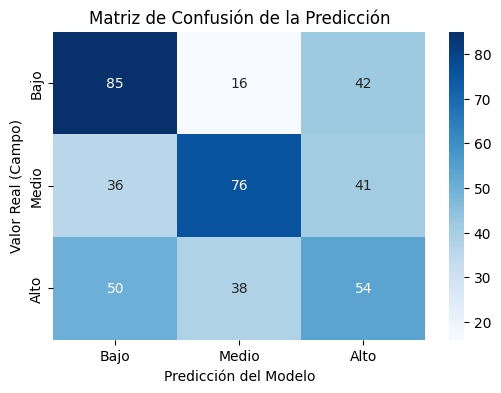

(0.4885335071923773,
 0.23720196490351197,
 array([[85, 16, 42],
        [36, 76, 41],
        [50, 38, 54]]))

In [14]:
y_pred_sac = best_knn_sac.predict(X_test_sac)

print("F1:", f1_score(y_test_sac, y_pred_sac, average="macro"))

evaluar_modelo(y_test_sac, y_pred_sac)

El modelo KNN obtuvo un F1 macro de aproximadamente 0.4885 en el conjunto de prueba, lo cual indica un desempeño moderado en la clasificación de las tres categorías de sacarosa.

Este resultado es superior al obtenido en la predicción de TCH, lo que sugiere que la variable sacarosa presenta una mejor separabilidad entre sus clases. Esto puede estar relacionado con una mayor consistencia en los factores que influyen en la calidad del cultivo frente al rendimiento.

El índice de Cohen’s Kappa fue de 0.2372, lo cual indica un nivel de acuerdo bajo a moderado entre las predicciones del modelo y los valores reales. Esto evidencia que, aunque el modelo logra capturar parte de la estructura de los datos, aún existen limitaciones en la capacidad de clasificación.

Al analizar la matriz de confusión, se observa que las clases "Bajo" y "Medio" presentan un mejor desempeño relativo, mientras que la clase "Alto" es la más difícil de predecir. Esta clase presenta confusión tanto con "Bajo" como con "Medio", lo que sugiere un solapamiento importante entre los niveles de sacarosa en el espacio de características.

## 7. Comparación entre los resultados arrojados por los modelos de clasificación de TCH y sacarosa

In [15]:
resumen = pd.DataFrame({
    "Objetivo": ["TCH", "Sacarosa"],
    "F1_KNN": [
        f1_score(y_test, y_pred_knn, average="macro"),
        f1_score(y_test_sac, y_pred_sac, average="macro")
    ]
})

resumen

,Objetivo,F1_KNN
0,TCH,0.414353
1,Sacarosa,0.488534


La tabla anterior permite comparar el desempeño del modelo KNN en ambas variables objetivo. Se observa que el modelo obtiene un F1 macro de aproximadamente 0.4144 para TCH y 0.4885 para sacarosa.

Esta diferencia muestra que el modelo KNN tuvo un mejor desempeño al clasificar los niveles de sacarosa que los niveles de TCH. Esto sugiere que, con las variables disponibles, la sacarosa presenta una mayor separabilidad entre clases, mientras que el rendimiento en TCH resulta más difícil de clasificar.

En ambos casos, el desempeño del modelo se considera moderado-bajo, lo cual indica que existe solapamiento entre las clases y que las variables predictoras no permiten una separación completamente clara de los niveles Bajo, Medio y Alto.

En comparación con la regresión logística, KNN no mejora el desempeño para TCH, pero sí permite evaluar un enfoque no lineal basado en la cercanía entre observaciones. Estos resultados sugieren que la utilidad de KNN depende de la estructura de cada variable objetivo y de qué tan claros sean los patrones locales en los datos.

## 8. Conclusiones

El modelo KNN permitió evaluar un enfoque no lineal basado en la cercanía entre observaciones, ofreciendo una alternativa al modelo de regresión logística. Debido a que KNN depende de la estructura local de los datos, su desempeño está condicionado por qué tan separadas se encuentren las clases en el espacio de características.

Los resultados muestran que KNN tuvo un mejor desempeño en la clasificación de sacarosa que en la clasificación de TCH, con un F1 macro de aproximadamente 0.4885 frente a 0.4144. Esto sugiere que los niveles de sacarosa presentan una mayor separabilidad relativa en comparación con los niveles de TCH.

Sin embargo, en comparación con la regresión logística, KNN no logró una mejora consistente, especialmente para TCH. Esto indica que, aunque el modelo puede capturar patrones locales, estos no fueron suficientemente claros para superar de forma general al modelo lineal.

En general, KNN complementa el análisis realizado con regresión logística al permitir explorar un enfoque basado en similitud entre observaciones. No obstante, los resultados obtenidos evidencian que el desempeño sigue siendo bajo, por lo que este modelo no resulta completamente eficiente para el problema y sería recomendable evaluar modelos más robustos.